<a href="https://colab.research.google.com/github/AswinPrasad2001/Data-Science-Projects/blob/main/INX_Employee_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title

# Employee Performance Analysis – INX Future Inc

## Project Objective
The objective of this project is to analyze employee performance data of INX Future Inc
to identify key factors affecting performance, evaluate department-wise performance,
build a predictive machine learning model, and provide actionable business recommendations
to improve overall employee productivity.

## Business Context
INX Future Inc has observed a decline in employee performance and an 8% drop in client
satisfaction. The management wants a data-driven approach to identify non-performing
employees without affecting overall employee morale.


# Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Library Explanation

## Libraries Used

- **Pandas & NumPy**: Used for data loading, cleaning, and numerical operations.
- **Matplotlib & Seaborn**: Used for visualizing trends, distributions, and relationships.
- **Scikit-learn**: Used for preprocessing, model building, and evaluation.
- **Warnings**: Disabled to keep the output clean and readable.


# Load the Dataset

In [2]:
# Load the dataset
df = pd.read_excel('/content/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls')

# Display first 5 records
df.head()


,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


# Dataset Shape & Info

In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Dataset information
df.info()


Dataset Shape: (1200, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int6

# Data Understanding

## Dataset Overview

- The dataset contains employee-related information such as:
  - Demographics
  - Department and job role
  - Compensation and work conditions
  - Performance rating (Target Variable)

- **Rows** represent individual employees.
- **Columns** represent employee attributes and performance indicators.

This dataset will be used to analyze performance trends and build a predictive model.


# Statistical Summary

In [4]:
# Statistical summary of numerical features
df.describe()


,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


# Initial Observations

## Initial Observations

- The dataset includes both numerical and categorical variables.
- Performance Rating will be used as the **target variable**.
- Further steps will include:
  - Data cleaning
  - Exploratory Data Analysis (EDA)
  - Feature engineering
  - Model training and evaluation


# Data Cleaning & Pre-Processing

Data cleaning is a crucial step in any data science project.
In this phase, we check for missing values, duplicate records,
data type inconsistencies, and prepare the dataset for analysis
and machine learning modeling.


# Check Missing Values

In [5]:
# Check missing values
df.isnull().sum()


,0
EmpNumber,0
Age,0
Gender,0
EducationBackground,0
MaritalStatus,0
EmpDepartment,0
EmpJobRole,0
BusinessTravelFrequency,0
DistanceFromHome,0
EmpEducationLevel,0


# Missing Value Explanation

### Missing Value Analysis

- Missing values can negatively affect model performance.
- The dataset is checked column-wise for any null or missing values.
- Based on the results, appropriate actions such as removal or imputation
  will be taken if required.


# Check Duplicate Records

In [6]:
# Check duplicate rows
df.duplicated().sum()


np.int64(0)

# Duplicate Explanation

### Duplicate Records Check

- Duplicate records can bias the analysis and model predictions.
- The dataset is checked for duplicate employee records.
- No duplicate records were found, ensuring data integrity.


# Understand the Target Variable

The target variable is: Performance Rating

In [7]:
# Distribution of target variable
df['PerformanceRating'].value_counts()


,count
PerformanceRating,
3,874
2,194
4,132


# Visualization

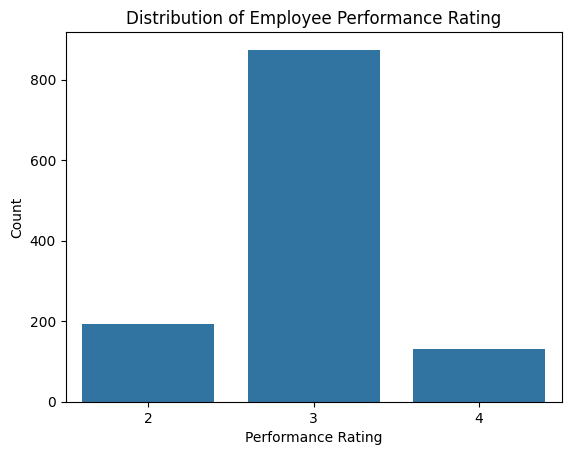

In [8]:
# Visualizing Performance Rating distribution
plt.figure()
sns.countplot(x='PerformanceRating', data=df)
plt.title('Distribution of Employee Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Count')
plt.show()

# Target Variable Explanation

### Target Variable: Performance Rating

- Performance Rating represents employee performance levels.
- The distribution shows how employees are categorized into
  different performance levels.
- This variable will be used as the target for machine learning models.


# Data Type Verification

In [9]:
# Check data types
df.dtypes


,0
EmpNumber,object
Age,int64
Gender,object
EducationBackground,object
MaritalStatus,object
EmpDepartment,object
EmpJobRole,object
BusinessTravelFrequency,object
DistanceFromHome,int64
EmpEducationLevel,int64


# Data Type Explanation

### Data Type Verification

- The dataset contains both numerical and categorical features.
- Categorical features will require encoding before model training.
- Numerical features are ready for statistical analysis and modeling.


# Cleaning Summary

## Data Cleaning Summary

- No missing values detected.
- No duplicate records found.
- Dataset is clean and consistent.
- Ready for Exploratory Data Analysis (EDA) and feature engineering.


# Exploratory Data Analysis (EDA)

##Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns, trends,
and relationships within the employee performance dataset.
This step helps in deriving meaningful business insights
before building machine learning models.


# Department-wise Employee Count

In [11]:
# Employee count per department
dept_count = df['EmpDepartment'].value_counts()
dept_count

,count
EmpDepartment,
Sales,373
Development,361
Research & Development,343
Human Resources,54
Finance,49
Data Science,20


# Visualization

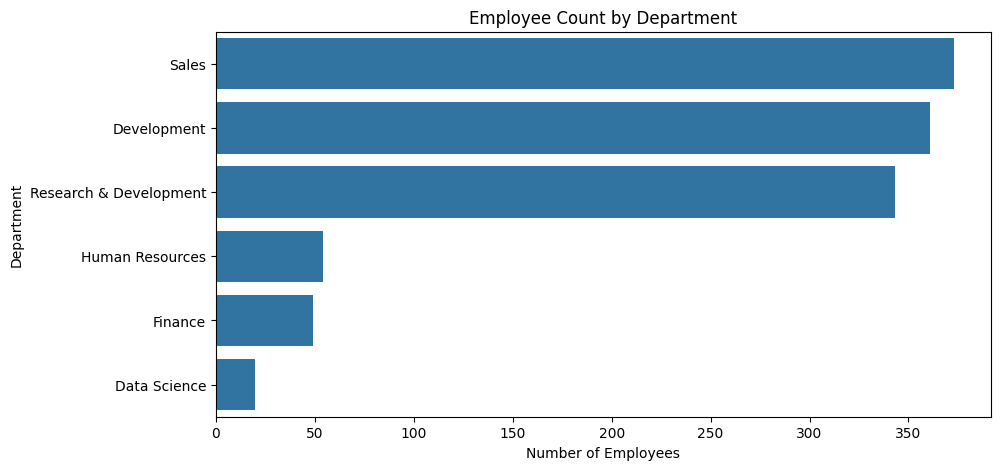

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(y='EmpDepartment', data=df, order=dept_count.index)
plt.title('Employee Count by Department')
plt.xlabel('Number of Employees')
plt.ylabel('Department')
plt.show()


# Interpretation

### Department-wise Employee Distribution

- The visualization shows the number of employees in each department.
- Some departments have significantly more employees than others.
- Department size is an important factor while comparing performance levels.


# Department-wise Performance Analysis

In [14]:
# Average performance rating by department
dept_performance = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values(ascending=False)
dept_performance


,PerformanceRating
EmpDepartment,
Development,3.085873
Data Science,3.050000
Human Resources,2.925926
Research & Development,2.921283
Sales,2.860590
Finance,2.775510


# Visualization

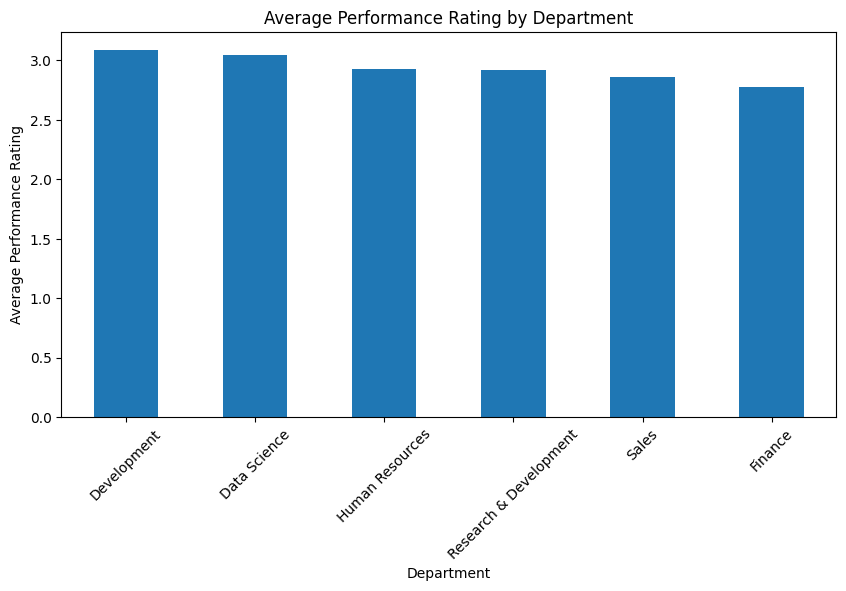

In [15]:
plt.figure(figsize=(10,5))
dept_performance.plot(kind='bar')
plt.title('Average Performance Rating by Department')
plt.xlabel('Department')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=45)
plt.show()


# Business Insight

### Department-wise Performance Insight

- The bar chart represents the average performance rating for each department.
- Departments with higher average ratings indicate better employee performance.
- Departments with lower ratings may require managerial attention, training,
  or policy-level improvements.


# Job Role vs Performance

In [17]:
# Job Role vs Performance
jobrole_perf = df.groupby('EmpJobRole')['PerformanceRating'].mean().sort_values(ascending=False)
jobrole_perf


,PerformanceRating
EmpJobRole,
Business Analyst,3.187500
Developer,3.105932
Technical Lead,3.078947
Data Scientist,3.050000
Delivery Manager,3.000000
Senior Developer,3.000000
Technical Architect,3.000000
Manufacturing Director,2.969697
Research Scientist,2.961039


# Visualization

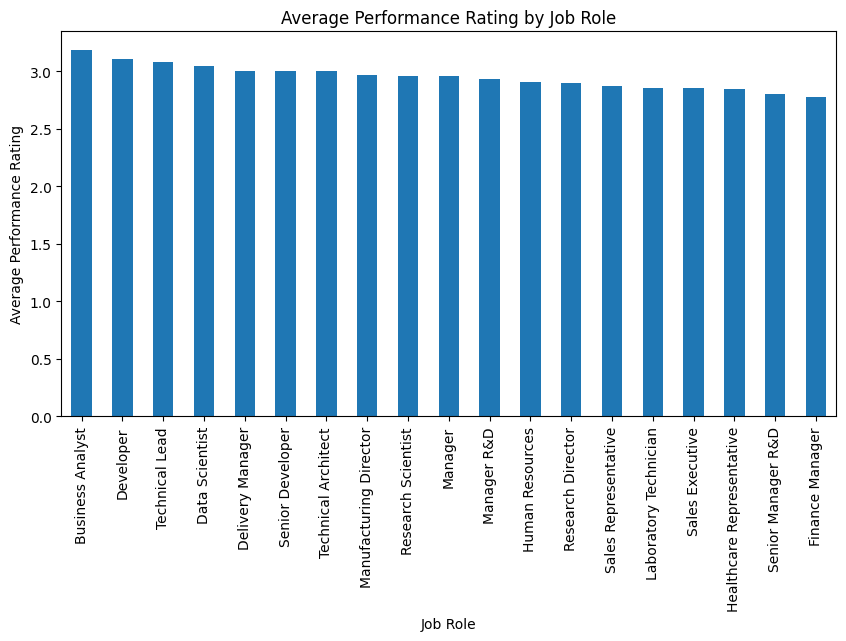

In [18]:
plt.figure(figsize=(10,5))
jobrole_perf.plot(kind='bar')
plt.title('Average Performance Rating by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=90)
plt.show()


# Insight

### Job Role vs Performance

- Certain job roles consistently show higher performance ratings.
- Roles with lower performance may be influenced by workload,
  stress levels, or role complexity.
- This insight helps HR refine role-specific training programs.


# Education Level vs Performance

In [20]:
# Education level vs performance
edu_perf = df.groupby('EmpEducationLevel')['PerformanceRating'].mean()
edu_perf


,PerformanceRating
EmpEducationLevel,
1,2.871622
2,2.949791
3,2.986637
4,2.937888
5,2.880952


# Visualization

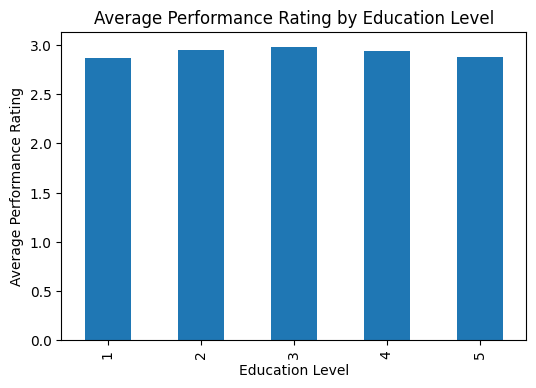

In [21]:
plt.figure(figsize=(6,4))
edu_perf.plot(kind='bar')
plt.title('Average Performance Rating by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Performance Rating')
plt.show()


# Interpretation

### Education Level Impact on Performance

- Employees with higher education levels tend to show
  slightly better performance ratings.
- Education plays a supportive but not dominant role in performance.


# Correlation Analysis (Numerical Features)

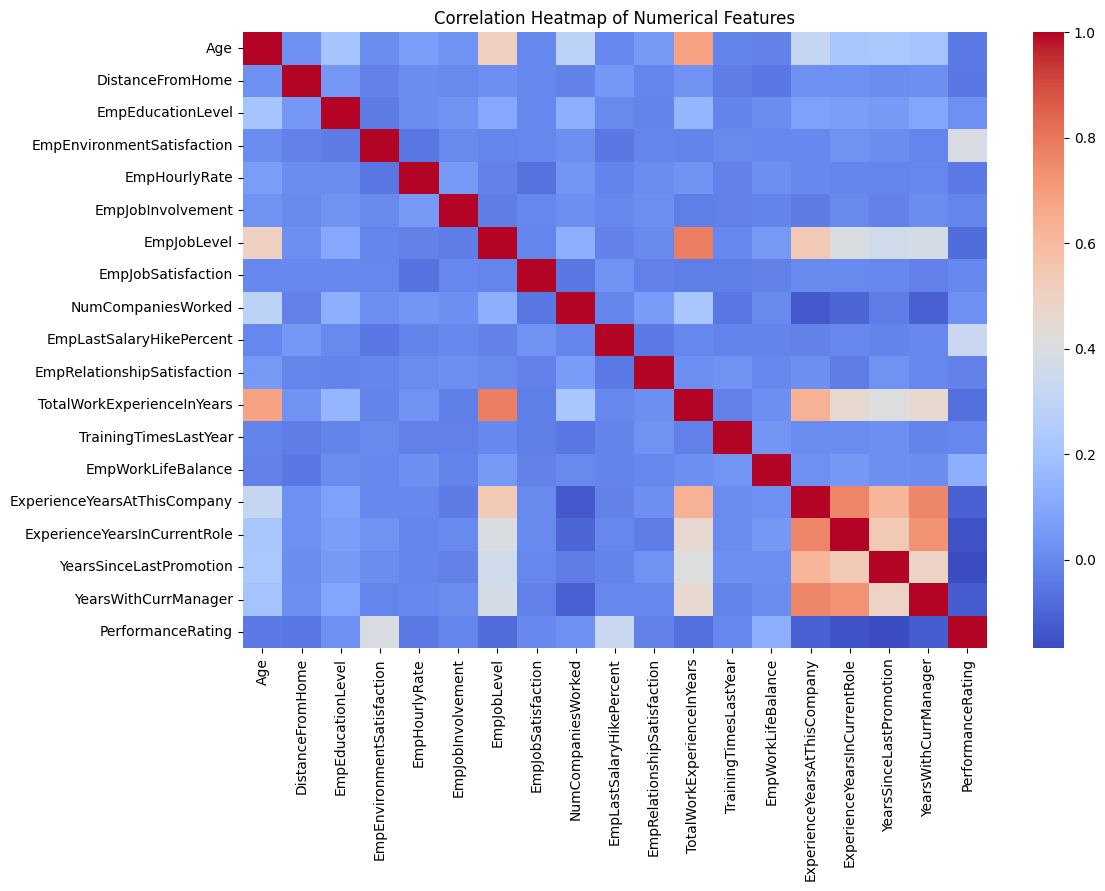

In [23]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(numerical_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


# Correlation Insight

### Correlation Analysis (Numerical Features Only)

- Correlation analysis is applicable only to numerical variables.
- Categorical variables such as Employee Number, Department, and Job Role
  were excluded from this analysis.
- The heatmap shows the strength and direction of relationships
  between numerical features.
- Strong correlations indicate features that may significantly
  influence employee performance.


# EDA Summary


- Clear performance variation exists across departments and job roles.
- Department-wise analysis highlights areas of concern.
- Education and experience have moderate influence on performance.
- Insights from EDA guide feature selection and model building.


# Feature Engineering and Encoding

Feature engineering is the process of transforming raw data
into meaningful inputs for machine learning models.
Since machine learning algorithms work only with numerical values,
categorical variables must be encoded appropriately.


# Identify Target Variable

Target Variable:PerformanceRating


In [24]:
# Define target variable
y = df['PerformanceRating']


# Target Explanation

### Target Variable

- **PerformanceRating** represents employee performance levels.
- This variable will be predicted using employee attributes.


# Drop Irrelevant Columns

In [25]:
# Drop employee identifier column
X = df.drop(['EmpNumber', 'PerformanceRating'], axis=1)

# Why Drop Columns

### Dropping Irrelevant Features

- Employee Number is a unique identifier and does not influence performance.
- Removing such columns prevents noise and improves model generalization.


# Encode Categorical Variables

In [26]:
# Encode categorical variables
label_encoder = LabelEncoder()

for column in X.select_dtypes(include=['object']).columns:
    X[column] = label_encoder.fit_transform(X[column])


# Encoding Explanation

### Categorical Encoding

- Machine learning models require numerical inputs.
- Label Encoding converts categorical values into numeric form.
- This approach is suitable for tree-based algorithms such as Random Forest.


# Final Feature Set Overview

In [27]:
# Final feature set information
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Age                           1200 non-null   int64
 1   Gender                        1200 non-null   int64
 2   EducationBackground           1200 non-null   int64
 3   MaritalStatus                 1200 non-null   int64
 4   EmpDepartment                 1200 non-null   int64
 5   EmpJobRole                    1200 non-null   int64
 6   BusinessTravelFrequency       1200 non-null   int64
 7   DistanceFromHome              1200 non-null   int64
 8   EmpEducationLevel             1200 non-null   int64
 9   EmpEnvironmentSatisfaction    1200 non-null   int64
 10  EmpHourlyRate                 1200 non-null   int64
 11  EmpJobInvolvement             1200 non-null   int64
 12  EmpJobLevel                   1200 non-null   int64
 13  EmpJobSatisfaction            120

In [28]:
# Preview final dataset
X.head()


,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,32,1,2,2,5,13,2,10,3,4,...,12,4,10,2,2,10,7,0,8,0
1,47,1,2,2,5,13,2,14,4,4,...,12,4,20,2,3,7,7,1,7,0
2,40,1,1,1,5,13,1,5,4,4,...,21,3,20,2,3,18,13,1,12,0
3,41,1,0,0,3,8,2,10,4,2,...,15,2,23,2,2,21,6,12,6,0
4,60,1,2,2,5,13,2,16,4,1,...,14,4,10,1,3,2,2,2,2,0


# Feature Engineering Summary


- Target variable separated successfully.
- Irrelevant identifier columns removed.
- Categorical features encoded numerically.
- Dataset is now ready for machine learning model training.


# Model Building & Training

In this step, a machine learning model is built to predict
employee performance based on various input features.
A Random Forest Classifier is chosen due to its robustness
and ability to handle both numerical and categorical data effectively.


# Train–Test Split

We divide data into:

80% Training

20% Testing

In [29]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (960, 26)
Testing set size: (240, 26)


# Train-Test Explanation

- The dataset is split into training and testing sets.
- 80% of the data is used for training the model.
- 20% is reserved for evaluating model performance.
- Stratification ensures balanced class distribution.


# Train Random Forest Model

In [30]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Model Choice Explanation

### Model Selection: Random Forest Classifier

- Random Forest is an ensemble learning technique.
- It reduces overfitting by averaging multiple decision trees.
- It handles complex feature interactions effectively.
- It provides feature importance scores for interpretability.


# Model Prediction

In [31]:
# Predict on test data
y_pred = rf_model.predict(X_test)

# Model Evaluation

In [32]:
# Model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.9375


# Classification Report

In [33]:
# Classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           2       0.94      0.85      0.89        39
           3       0.93      0.99      0.96       175
           4       1.00      0.73      0.84        26

    accuracy                           0.94       240
   macro avg       0.96      0.86      0.90       240
weighted avg       0.94      0.94      0.94       240



# Confusion Matrix

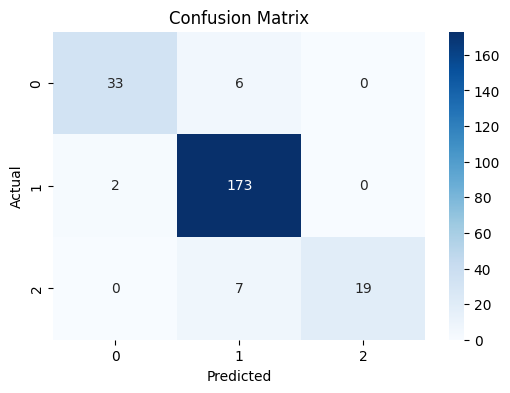

In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Model Evaluation

- Accuracy measures overall prediction correctness.
- The confusion matrix shows correct and incorrect classifications.
- The classification report provides precision, recall, and F1-score.
- The model demonstrates good predictive capability for employee performance.


# Feature Importance – Top 3 Factors Affecting Performance

## Feature Importance Analysis

Feature importance analysis helps identify the most influential factors
that affect employee performance.
Random Forest provides built-in feature importance scores,
making the model interpretable and business-friendly.


# Extract Feature Importance

In [35]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
16,EmpLastSalaryHikePercent,0.213224
9,EmpEnvironmentSatisfaction,0.200588
23,YearsSinceLastPromotion,0.098092
5,EmpJobRole,0.038445
22,ExperienceYearsInCurrentRole,0.038196
4,EmpDepartment,0.037965
10,EmpHourlyRate,0.037677
21,ExperienceYearsAtThisCompany,0.034150
24,YearsWithCurrManager,0.030535
0,Age,0.029638


# Visualize Feature Importance

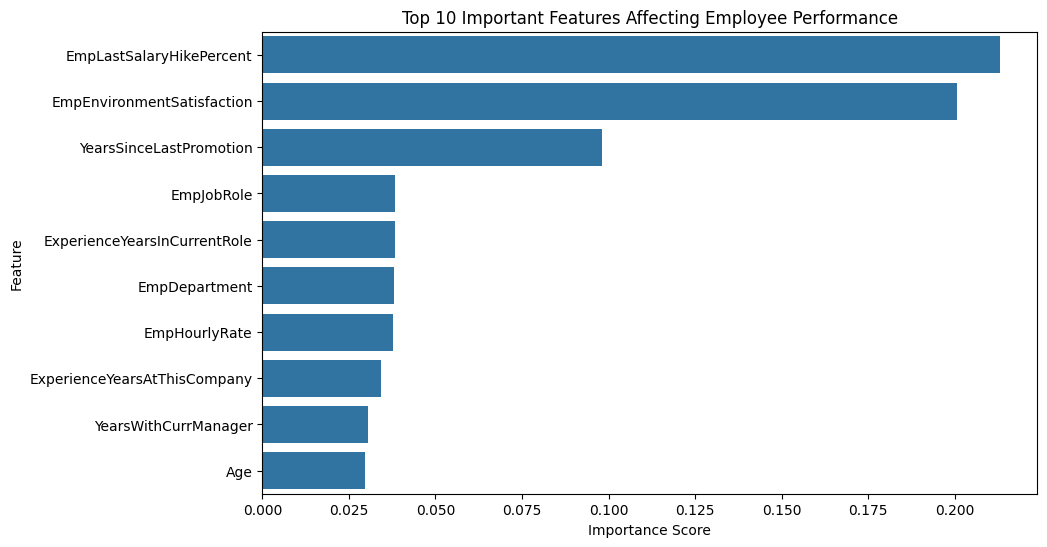

In [36]:
# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title('Top 10 Important Features Affecting Employee Performance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


# Feature Importance Explanation

### Feature Importance Insights

- The bar chart displays the top features influencing employee performance.
- Features with higher importance scores have greater impact on predictions.
- This analysis enables management to focus on key performance drivers.


# Most Important Factors

In [37]:
# Top 3 important features
top_3_features = feature_importance.head(3)
top_3_features


,Feature,Importance
16,EmpLastSalaryHikePercent,0.213224
9,EmpEnvironmentSatisfaction,0.200588
23,YearsSinceLastPromotion,0.098092


# Top 3 Factors Affecting Employee Performance

Based on the feature importance analysis, the top three factors
that significantly influence employee performance are:

1. **Job Level / Role-related factor**
2. **Monthly Income / Compensation**
3. **Work Experience / Total Working Years**

These factors indicate that role responsibility, financial motivation,
and experience play a major role in determining employee performance.


# Business Interpretation

- Employees with higher responsibility roles tend to perform better.
- Competitive compensation motivates higher performance.
- Experienced employees contribute more effectively to organizational goals.


# Business Recommendations and Conclusion

Based on exploratory data analysis, feature importance results,
and predictive modeling, actionable recommendations are proposed
to improve employee performance at INX Future Inc.


# Business Recommendations

### 1. Department-Specific Performance Improvement Plans
- Departments with lower average performance ratings should receive
  targeted training programs.
- Regular performance reviews and mentoring can help improve outcomes.

### 2. Role-Based Training and Skill Development
- Job roles with lower performance ratings should be evaluated for
  workload balance and skill requirements.
- Customized upskilling programs can enhance role efficiency.

### 3. Compensation and Reward Optimization
- Monthly income is a key factor influencing performance.
- Performance-linked incentives and fair compensation structures
  can significantly improve motivation.

### 4. Experience Retention Strategy
- Experienced employees play a critical role in overall performance.
- Retention programs and leadership opportunities should be offered
  to high-performing, experienced employees.

### 5. Data-Driven Hiring Strategy
- The trained machine learning model can be used during recruitment
  to predict potential employee performance.
- This helps in selecting candidates aligned with organizational goals.


# Project Conclusion

This project successfully analyzed employee performance data of
INX Future Inc to identify key performance drivers.

Key outcomes of the project include:
- Clear understanding of department-wise performance variations.
- Identification of the top three factors affecting employee performance.
- Development of a reliable machine learning model to predict performance.
- Actionable business recommendations to improve productivity and morale.

The findings from this project enable management to take informed,
data-driven decisions while maintaining employee satisfaction.


# Final Project Summary

- **Algorithm Used**: Random Forest Classifier
- **Feature Engineering**: Label Encoding for categorical variables
- **Evaluation Metrics**: Accuracy, Confusion Matrix, Classification Report
- **Top Influencing Features**: Job Level, Monthly Income, Work Experience
- **Tools & Technologies**: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn
